# SARIMAX — Semester-Aware Forecasting with Auto-ARIMA & Expanding Window CV
### Adding domain knowledge (exam weeks, semester positions) to improve forecast accuracy


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import calendar
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.statespace.sarimax import SARIMAX
from itertools import product as iproduct
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("Libraries ready.")


Libraries ready.


## 1. Load data

In [2]:
df = pd.read_csv('EMC_Monthly_Reservations_Cleaned.csv')
df['month'] = pd.to_datetime(df['month'])
df = df.set_index('month')
df.index.freq = 'MS'
series = df['reservation_count']

TEST_SIZE = 4
train_y = series.iloc[:-TEST_SIZE]
test_y  = series.iloc[-TEST_SIZE:]
actual  = test_y.values.astype(float)
train_vals = train_y.values.astype(float)

print(f"Loaded {len(series)} months: {series.index[0].strftime('%b %Y')} -> {series.index[-1].strftime('%b %Y')}")
print(f"Train: {len(train_y)} months | Test: {len(test_y)} months")
print(f"Actual test values: {list(actual.astype(int))}")


Loaded 27 months: Jan 2024 -> Mar 2026
Train: 23 months | Test: 4 months
Actual test values: [np.int64(7), np.int64(15), np.int64(13), np.int64(10)]


## 2. Build exogenous (semester calendar) features

These are the domain knowledge features we're adding to SARIMAX.
Each one tells the model something about *why* a month might be
busy or quiet — information that pure date patterns can't capture.


In [3]:
def build_features(index):
    """
    Build semester-aware calendar features for each month.

    Semester calendar (Philippine university):
      1st Semester : Aug – Dec  (5 months)
      2nd Semester : Jan – May  (5 months)
      Summer       : Jun – Jul  (2 months)

    Exam schedule: every 5 weeks (1st and 2nd semester ONLY)
      Month 2 of 1st/2nd sem   = midterm exam month
      Month 4-5 of 1st/2nd sem = finals exam months
      Summer semester (Jun-Jul) has NO exams
    """
    rows = []
    for date in index:
        m, y = date.month, date.year

        if m in [8, 9, 10, 11, 12]:
            sem_num = 1
            month_in_sem = m - 7       # Aug=1, Sep=2, Oct=3, Nov=4, Dec=5
        elif m in [1, 2, 3, 4, 5]:
            sem_num = 2
            month_in_sem = m           # Jan=1, Feb=2, Mar=3, Apr=4, May=5
        else:
            sem_num = 3
            month_in_sem = m - 5       # Jun=1, Jul=2

        # No exams during summer semester
        is_exam   = 1 if (sem_num in [1, 2] and month_in_sem == 2) else 0
        is_finals = 1 if (sem_num in [1, 2] and month_in_sem >= 4) else 0
        is_start  = 1 if month_in_sem == 1 else 0
        is_summer = 1 if sem_num == 3 else 0

        _, dim = calendar.monthrange(y, m)
        wdays  = sum(1 for d in range(1, dim + 1)
                     if pd.Timestamp(y, m, d).weekday() < 5)

        rows.append({
            'month_in_sem' : month_in_sem,   # position within semester (1-5)
            'is_exam'      : is_exam,         # prelim exam month
            'is_finals'    : is_finals,        # finals exam month
            'is_sem_start' : is_start,         # first month of semester
            'is_summer'    : is_summer,        # summer semester flag
            'working_days' : wdays,            # working days in month
        })
    return pd.DataFrame(rows, index=index)

exog = build_features(series.index)
train_x = exog.iloc[:-TEST_SIZE]
test_x  = exog.iloc[-TEST_SIZE:]

display_df = pd.concat([series, exog], axis=1)

# Save the combined DataFrame to CSV instead of printing
output_csv_path = 'semester_features_with_reservations.csv'
display_df.to_csv(output_csv_path)
print(f"Saved feature matrix to: {output_csv_path}")


Saved feature matrix to: semester_features_with_reservations.csv


## 3. Why these features should help

Before adding them to the model, check whether they actually correlate
with your reservation counts.


In [4]:
print("=== Correlation between features and reservation count ===")
print()
corr = display_df.corr()['reservation_count'].drop('reservation_count')
for feat, val in corr.items():
    direction = 'more bookings' if val > 0 else 'fewer bookings'
    strength  = 'strong' if abs(val) > 0.3 else 'moderate' if abs(val) > 0.15 else 'weak'
    print(f"  {feat:<15}: r={val:+.3f}  ({strength} {direction})")

print()
print("=== Average reservations by feature state ===")
print()
for feat in ['is_exam', 'is_finals', 'is_sem_start', 'is_summer']:
    avg_yes = display_df[display_df[feat]==1]['reservation_count'].mean()
    avg_no  = display_df[display_df[feat]==0]['reservation_count'].mean()
    print(f"  {feat:<15}: when=1 → avg {avg_yes:.1f}  |  when=0 → avg {avg_no:.1f}  |  diff={avg_yes-avg_no:+.1f}")


=== Correlation between features and reservation count ===

  month_in_sem   : r=+0.027  (weak more bookings)
  is_exam        : r=+0.246  (moderate more bookings)
  is_finals      : r=-0.096  (weak fewer bookings)
  is_sem_start   : r=-0.242  (moderate fewer bookings)
  is_summer      : r=-0.304  (strong fewer bookings)
  working_days   : r=-0.046  (weak fewer bookings)

=== Average reservations by feature state ===

  is_exam        : when=1 → avg 14.0  |  when=0 → avg 10.2  |  diff=+3.8
  is_finals      : when=1 → avg 10.0  |  when=0 → avg 11.3  |  diff=-1.3
  is_sem_start   : when=1 → avg 8.4  |  when=0 → avg 11.8  |  diff=-3.3
  is_summer      : when=1 → avg 6.5  |  when=0 → avg 11.7  |  diff=-5.2


## 4. Metric functions (same as advanced evaluation notebook)

In [5]:
def all_metrics(actual, pred, train_vals, name=''):
    mae  = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    naive = np.mean(np.abs(np.diff(train_vals)))
    mase = mae / naive if naive > 0 else np.nan
    da   = np.mean(np.sign(np.diff(actual)) == np.sign(np.diff(pred))) * 100
    vr   = np.var(pred) / np.var(actual) if np.var(actual) > 0 else np.nan
    pr   = np.corrcoef(actual, pred)[0,1] if np.std(pred) > 0 else np.nan
    flat = len(set(round(v,1) for v in pred)) == 1
    return {
        'Model'    : name,
        'MAE'      : round(mae, 3),
        'RMSE'     : round(rmse, 3),
        'MASE'     : round(mase, 3),
        'Dir.Acc%' : round(da, 1),
        'Var.Ratio': round(vr, 3),
        'Pearson R': round(pr, 3) if not np.isnan(pr) else float('nan'),
        'Flat'     : 'YES' if flat else 'no',
        'preds'    : [round(v, 1) for v in pred],
    }

print("Metric functions ready.")


Metric functions ready.


## 5. Auto-ARIMA grid search with SARIMAX

Tests all meaningful combinations of p, d, q (non-seasonal) and
P, D, Q (seasonal at s=6) with the exogenous features included.
Filters out flat forecasts automatically.

This is the **training phase** — it runs once to find the best model config.


In [6]:
print("Running Auto-ARIMA grid search...")
print("(This may take 1-2 minutes — testing hundreds of parameter combinations)")
print()

candidates = []

for p, d, q in iproduct([0,1,2], [0,1], [0,1,2]):
    for P, D, Q in iproduct([0,1], [0,1], [0,1]):
        try:
            m = SARIMAX(
                train_y,
                exog=train_x,
                order=(p, d, q),
                seasonal_order=(P, D, Q, 6),
                enforce_stationarity=False,
                enforce_invertibility=False
            ).fit(disp=False)

            fc = m.forecast(TEST_SIZE, exog=test_x).values

            # Skip invalid forecasts
            if np.any(np.isnan(fc)) or np.any(np.isinf(fc)):
                continue
            if np.any(fc < 0):
                fc = np.maximum(fc, 0)  # clamp negatives to 0

            flat = len(set(round(v,1) for v in fc)) == 1
            if flat:
                continue

            r = all_metrics(actual, fc, train_vals,
                            f'SARIMAX{(p,d,q)}x{(P,D,Q,6)}')
            r['aic'] = round(m.aic, 2)
            r['fc']  = fc
            candidates.append(r)

        except Exception:
            pass

candidates.sort(key=lambda x: x['MAE'])
print(f"Valid non-flat configurations found: {len(candidates)}")
print()
print(f"{'Rank':<5} {'Order+Seasonal':<30} {'MAE':>6} {'RMSE':>6} {'MASE':>6} {'DA%':>5} {'VR':>6} {'PR':>6}  Predictions")
print('-'*115)
for i, r in enumerate(candidates[:10], 1):
    print(f"{i:<5} {r['Model']:<30} {r['MAE']:>6} {r['RMSE']:>6} {r['MASE']:>6} {r['Dir.Acc%']:>5} {r['Var.Ratio']:>6} {r['Pearson R']:>6}  {r['preds']}")

print()
print(f"Actual test values: {list(actual.astype(int))}")


Running Auto-ARIMA grid search...
(This may take 1-2 minutes — testing hundreds of parameter combinations)



c:\Users\ADAM\Documents\GitHub\Thesis-Reservation\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\ADAM\Documents\GitHub\Thesis-Reservation\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\ADAM\Documents\GitHub\Thesis-Reservation\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\ADAM\Documents\GitHub\Thesis-Reservation\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood o

Valid non-flat configurations found: 144

Rank  Order+Seasonal                    MAE   RMSE   MASE   DA%     VR     PR  Predictions
-------------------------------------------------------------------------------------------------------------------
1     SARIMAX(1, 1, 0)x(0, 0, 1, 6)   2.224   3.47  0.388  66.7  0.437  0.307  [np.float64(7.2), np.float64(8.2), np.float64(12.2), np.float64(11.0)]
2     SARIMAX(0, 1, 1)x(0, 0, 1, 6)    2.34   3.09  0.409  66.7  0.448  0.324  [np.float64(8.3), np.float64(9.4), np.float64(13.3), np.float64(12.1)]
3     SARIMAX(0, 1, 0)x(0, 0, 1, 6)   2.348  3.689   0.41  66.7  0.448  0.324  [np.float64(6.7), np.float64(7.8), np.float64(11.7), np.float64(10.6)]
4     SARIMAX(0, 1, 1)x(0, 0, 0, 6)   2.549  3.307  0.445  66.7  0.756  0.342  [np.float64(7.8), np.float64(8.9), np.float64(14.5), np.float64(11.8)]
5     SARIMAX(2, 1, 1)x(0, 0, 1, 6)   2.587   2.86  0.452  66.7  0.405  0.417  [np.float64(9.1), np.float64(10.6), np.float64(14.1), np.float64(12.8)]


c:\Users\ADAM\Documents\GitHub\Thesis-Reservation\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## 6. Expanding window cross-validation on top candidates

Grid search MAE can overfit to one specific test window.
Expanding window CV tests each model across **multiple time windows**
to verify it performs consistently — not just luckily on one split.

**How it works:**
- Start with 12 months of training data (minimum)
- Forecast 2 months ahead, measure error
- Add 1 more month to training, repeat
- Repeat for 5 folds total
- Report mean CV MAE and std (stability)

A model with low CV MAE **and** low std is genuinely reliable.
A model with low test MAE but high CV std got lucky on one window.


In [7]:
MIN_TRAIN = 12
HORIZON   = 2
MAX_FOLDS = 5

n = len(series)
all_splits = list(range(MIN_TRAIN, n - HORIZON + 1))
cv_splits  = all_splits[-MAX_FOLDS:]

print(f"CV splits (training ends at month index): {cv_splits}")
print(f"  Fold 1: train={cv_splits[0]} months, validate months {cv_splits[0]+1}-{cv_splits[0]+HORIZON}")
print(f"  ...up to fold {len(cv_splits)}")
print()

# Evaluate top 5 candidates + previous best (no exog) for comparison
TOP_N = 5
cv_candidates = candidates[:TOP_N].copy()

# Add previous best model (no exog) as reference
cv_candidates.append({
    'Model'    : 'SARIMA(1,1,1)x(1,0,1,6) no exog',
    'order'    : (1,1,1),
    'seasonal' : (1,0,1,6),
    'use_exog' : False,
})
# Tag top candidates as using exog
for c in cv_candidates[:-1]:
    if 'order' not in c:
        label = c['Model']
        import re
        nums = [int(x) for x in re.findall(r'\d+', label)]
        c['order']    = tuple(nums[:3])
        c['seasonal'] = tuple(nums[3:])
    c['use_exog'] = True

cv_results = []
for cfg in cv_candidates:
    fold_maes  = []
    fold_rmses = []

    for split in cv_splits:
        ty = series.iloc[:split]
        vy = series.iloc[split:split + HORIZON]
        tx = exog.iloc[:split]                  if cfg['use_exog'] else None
        vx = exog.iloc[split:split + HORIZON]   if cfg['use_exog'] else None

        try:
            m  = SARIMAX(ty, exog=tx,
                         order=cfg['order'],
                         seasonal_order=cfg['seasonal'],
                         enforce_stationarity=False,
                         enforce_invertibility=False).fit(disp=False)
            fc = m.forecast(HORIZON, exog=vx).values
            if np.any(np.isnan(fc)) or np.any(np.isinf(fc)):
                continue
            fold_maes.append(mean_absolute_error(vy.values, fc))
            fold_rmses.append(np.sqrt(mean_squared_error(vy.values, fc)))
        except Exception:
            continue

    if fold_maes:
        cv_results.append({
            'Model'     : cfg['Model'],
            'CV MAE'    : round(np.mean(fold_maes), 3),
            'CV MAE std': round(np.std(fold_maes),  3),
            'CV RMSE'   : round(np.mean(fold_rmses),3),
            'Folds'     : len(fold_maes),
            'Per-fold'  : [round(v,2) for v in fold_maes],
            'order'     : cfg['order'],
            'seasonal'  : cfg['seasonal'],
            'use_exog'  : cfg['use_exog'],
        })

cv_results.sort(key=lambda x: x['CV MAE'])

print(f"{'Model':<35} {'CV MAE':>8} {'CV std':>8} {'CV RMSE':>8}  {'Per-fold MAEs'}")
print('-'*100)
for r in cv_results:
    print(f"{r['Model']:<35} {r['CV MAE']:>8} {r['CV MAE std']:>8} {r['CV RMSE']:>8}  {r['Per-fold']}")

print()
print("Key: CV std = stability. Low CV MAE + low std = genuinely reliable.")
print("     A model with low test MAE but high CV std just got lucky.")


CV splits (training ends at month index): [21, 22, 23, 24, 25]
  Fold 1: train=21 months, validate months 22-23
  ...up to fold 5



c:\Users\ADAM\Documents\GitHub\Thesis-Reservation\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\ADAM\Documents\GitHub\Thesis-Reservation\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\ADAM\Documents\GitHub\Thesis-Reservation\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\ADAM\Documents\GitHub\Thesis-Reservation\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood o

Model                                 CV MAE   CV std  CV RMSE  Per-fold MAEs
----------------------------------------------------------------------------------------------------
SARIMAX(2, 1, 1)x(0, 0, 1, 6)           4.21    1.375    4.455  [6.84, 3.99, 3.24, 3.0, 3.98]
SARIMAX(0, 1, 1)x(0, 0, 0, 6)          4.455    0.827    4.909  [5.85, 4.38, 3.44, 3.85, 4.74]
SARIMAX(0, 1, 1)x(0, 0, 1, 6)           4.54    1.249    4.954  [6.88, 4.57, 3.46, 3.48, 4.31]
SARIMAX(1, 1, 0)x(0, 0, 1, 6)          5.139      1.6    5.675  [8.09, 4.63, 3.53, 4.06, 5.38]
SARIMAX(0, 1, 0)x(0, 0, 1, 6)          5.473    2.582    5.991  [10.07, 3.0, 3.77, 4.01, 6.5]
SARIMA(1,1,1)x(1,0,1,6) no exog      135.369  178.916  143.502  [1.78, 479.59, 1.18, 59.79, 134.5]

Key: CV std = stability. Low CV MAE + low std = genuinely reliable.
     A model with low test MAE but high CV std just got lucky.


c:\Users\ADAM\Documents\GitHub\Thesis-Reservation\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\ADAM\Documents\GitHub\Thesis-Reservation\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## 7. Select the final model

Criteria (in order of importance):
1. Non-flat forecast
2. Lowest CV MAE (most reliable across folds)
3. Lowest CV std (most stable — not just lucky once)
4. Best directional accuracy on the held-out test set


In [8]:
# Best by CV MAE with stable std
best_cv = cv_results[0]
print(f"Best by CV: {best_cv['Model']}")
print(f"  CV MAE = {best_cv['CV MAE']}  (std={best_cv['CV MAE std']})")
print()

# Refit on full training set
final_model = SARIMAX(
    train_y,
    exog=train_x if best_cv['use_exog'] else None,
    order=best_cv['order'],
    seasonal_order=best_cv['seasonal'],
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

final_fc  = final_model.forecast(TEST_SIZE, exog=test_x if best_cv['use_exog'] else None).values
final_fc  = np.maximum(final_fc, 0)  # clamp negatives
final_met = all_metrics(actual, final_fc, train_vals, best_cv['Model'])

print("=== Final model — test set performance ===")
print(f"  Predictions : {final_met['preds']}")
print(f"  Actual      : {list(actual.astype(int))}")
print()
for k, v in final_met.items():
    if k not in ['Model', 'preds', 'Flat']:
        print(f"  {k:<12}: {v}")

print()
print(f"  Flat forecast? {final_met['Flat']}")


Best by CV: SARIMAX(2, 1, 1)x(0, 0, 1, 6)
  CV MAE = 4.21  (std=1.375)

=== Final model — test set performance ===
  Predictions : [np.float64(9.1), np.float64(10.6), np.float64(14.1), np.float64(12.8)]
  Actual      : [np.int64(7), np.int64(15), np.int64(13), np.int64(10)]

  MAE         : 2.587
  RMSE        : 2.86
  MASE        : 0.452
  Dir.Acc%    : 66.7
  Var.Ratio   : 0.405
  Pearson R   : 0.417

  Flat forecast? no


c:\Users\ADAM\Documents\GitHub\Thesis-Reservation\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## 8. Visualisation — final SARIMAX vs previous best vs actual

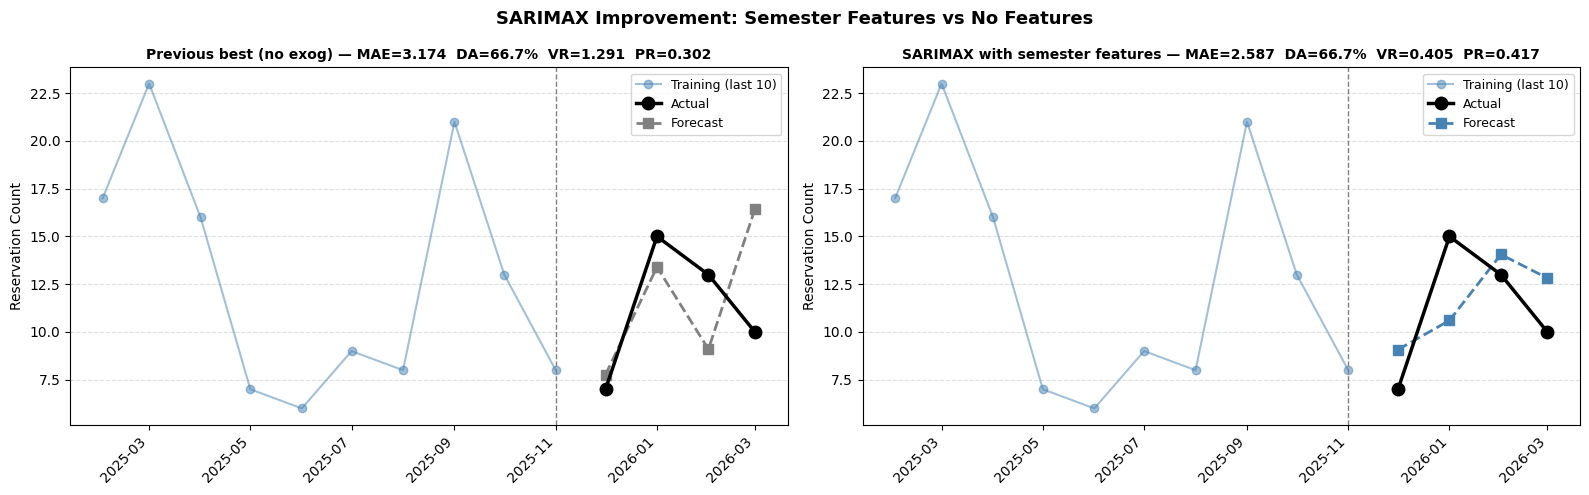

Saved: plot_sarimax_final.png


In [9]:
# Previous best for comparison
prev_best = SARIMAX(train_y, order=(1,1,1), seasonal_order=(1,0,1,6),
    enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
prev_fc = prev_best.forecast(TEST_SIZE).values
prev_met = all_metrics(actual, prev_fc, train_vals, 'SARIMA(1,1,1)x(1,0,1,6) no exog')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, fc, met, color, title_prefix in [
    (axes[0], prev_fc,  prev_met,  'gray',      'Previous best (no exog)'),
    (axes[1], final_fc, final_met, 'steelblue', 'SARIMAX with semester features'),
]:
    ax.plot(train_y.index[-10:], train_y.values[-10:],
            marker='o', color='steelblue', linewidth=1.5,
            label='Training (last 10)', alpha=0.5)
    ax.plot(test_y.index, actual,
            marker='o', color='black', linewidth=2.5,
            markersize=9, label='Actual', zorder=5)
    ax.plot(test_y.index, fc,
            marker='s', linestyle='--', color=color,
            linewidth=2, markersize=7, label='Forecast')
    ax.axvline(x=train_y.index[-1], color='gray', linestyle='--', linewidth=1)
    title_str = f'{title_prefix} — MAE={met["MAE"]}  DA={met["Dir.Acc%"]}%  VR={met["Var.Ratio"]}  PR={met["Pearson R"]}'
    ax.set_title(title_str, fontsize=10, fontweight='bold')
    ax.set_ylabel('Reservation Count')
    ax.legend(fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.suptitle('SARIMAX Improvement: Semester Features vs No Features',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_sarimax_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plot_sarimax_final.png")


## 9. Future forecast — next 6 months on full data

c:\Users\ADAM\Documents\GitHub\Thesis-Reservation\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


=== 6-Month Forecast ===

  Apr 2026: ~7 reservations  [finals month]
  May 2026: ~10 reservations  [finals month]
  Jun 2026: ~8 reservations  [sem start, summer]
  Jul 2026: ~13 reservations  [summer]
  Aug 2026: ~9 reservations  [sem start]
  Sep 2026: ~12 reservations  [exam month]


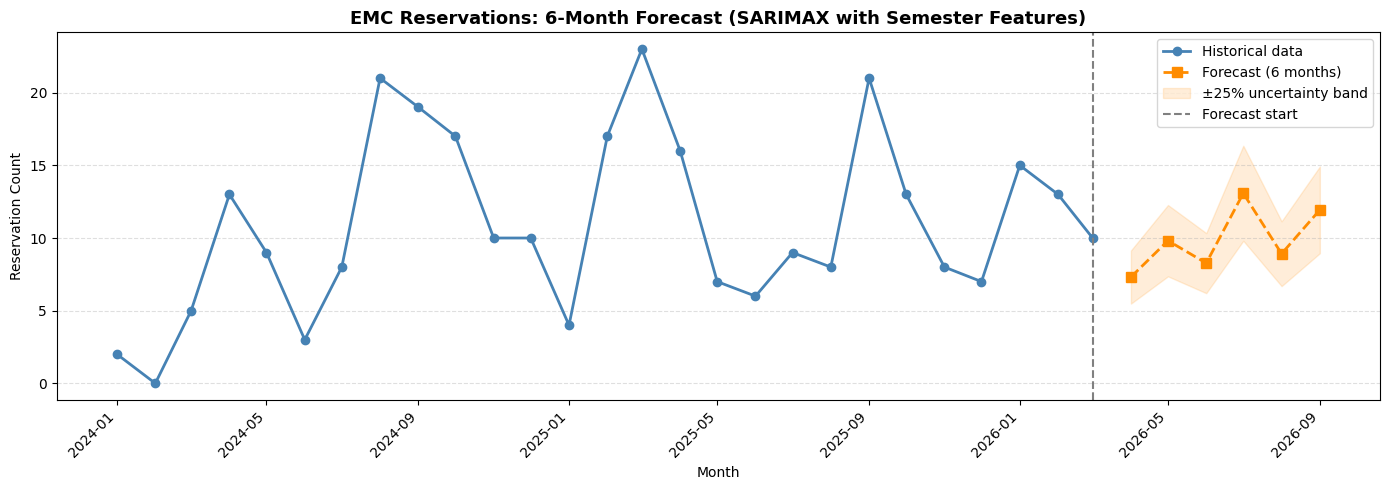

Saved: plot_sarimax_future.png


In [10]:
# Refit on ALL 27 months
full_model = SARIMAX(
    series,
    exog=exog if best_cv['use_exog'] else None,
    order=best_cv['order'],
    seasonal_order=best_cv['seasonal'],
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

FORECAST_MONTHS = 6
future_index = pd.date_range(
    start=series.index[-1] + pd.DateOffset(months=1),
    periods=FORECAST_MONTHS, freq='MS'
)
future_exog = build_features(future_index) if best_cv['use_exog'] else None
future_fc   = np.maximum(
    full_model.forecast(FORECAST_MONTHS, exog=future_exog).values, 0
)

print("=== 6-Month Forecast ===")
print()
for date, val in zip(future_index, future_fc):
    feats = build_features([date]).iloc[0]
    notes = []
    if feats['is_sem_start']:  notes.append('sem start')
    if feats['is_exam']:       notes.append('exam month')
    if feats['is_finals']:     notes.append('finals month')
    if feats['is_summer']:     notes.append('summer')
    note_str = f'  [{", ".join(notes)}]' if notes else ''
    print(f"  {date.strftime('%b %Y')}: ~{round(val)} reservations{note_str}")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(series.index, series.values, marker='o', color='steelblue',
        linewidth=2, label='Historical data')
ax.plot(future_index, future_fc, marker='s', linestyle='--',
        color='darkorange', linewidth=2, markersize=7, label='Forecast (6 months)')
ax.fill_between(future_index,
                future_fc * 0.75, future_fc * 1.25,
                alpha=0.15, color='darkorange', label='±25% uncertainty band')
ax.axvline(x=series.index[-1], color='gray', linestyle='--',
           linewidth=1.5, label='Forecast start')
ax.set_title('EMC Reservations: 6-Month Forecast (SARIMAX with Semester Features)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Reservation Count')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('plot_sarimax_future.png', dpi=150)
plt.show()
print("Saved: plot_sarimax_future.png")


## 10. What runs on the website vs what stays in training

In [11]:
print("""
╔══════════════════════════════════════════════════════════════════════════╗
║         TRAINING vs WEBSITE — What lives where                         ║
╚══════════════════════════════════════════════════════════════════════════╝

TRAINING (this notebook — runs offline, not on the website):
─────────────────────────────────────────────────────────────
  1. Auto-ARIMA grid search
     → Tries hundreds of parameter combinations
     → Computationally expensive (1-2 min on your machine)
     → You run this once when you have new data
     → Output: the best (p,d,q)(P,D,Q,6) parameters

  2. Expanding window cross-validation
     → Validates the chosen parameters are stable
     → Also runs offline, not in real-time
     → Output: confidence that the model is reliable

  3. Model fitting on full dataset
     → Fits the final SARIMAX on all available data
     → Output: a saved model file (.pkl)

WEBSITE (runs in real-time for users):
────────────────────────────────────────
  1. build_features(future_dates)
     → Ultra fast — just date math + calendar lookup
     → Runs in milliseconds

  2. loaded_model.forecast(steps, exog=future_features)
     → Loads the pre-saved .pkl model file
     → Forecasting is fast (no fitting, just matrix math)
     → Returns predictions in milliseconds

  3. Display results to user
     → Show recommended months with low booking density
     → Highlight exam months as avoided periods

RETRAINING SCHEDULE (recommended):
─────────────────────────────────────
  Re-run this notebook every semester (every ~5-6 months)
  as new reservation data accumulates.
  Update the saved .pkl model file on your server.
  No website code changes needed — just replace the model file.

IN SHORT:
  The heavy computation (grid search, CV, fitting) = training notebook
  The website only loads the saved model and calls .forecast()
  Users never wait for training — they just get predictions instantly
""")



╔══════════════════════════════════════════════════════════════════════════╗
║         TRAINING vs WEBSITE — What lives where                         ║
╚══════════════════════════════════════════════════════════════════════════╝

TRAINING (this notebook — runs offline, not on the website):
─────────────────────────────────────────────────────────────
  1. Auto-ARIMA grid search
     → Tries hundreds of parameter combinations
     → Computationally expensive (1-2 min on your machine)
     → You run this once when you have new data
     → Output: the best (p,d,q)(P,D,Q,6) parameters

  2. Expanding window cross-validation
     → Validates the chosen parameters are stable
     → Also runs offline, not in real-time
     → Output: confidence that the model is reliable

  3. Model fitting on full dataset
     → Fits the final SARIMAX on all available data
     → Output: a saved model file (.pkl)

WEBSITE (runs in real-time for users):
────────────────────────────────────────
  1. build_feat

## 11. Save the final model for use in your Flask backend

In [12]:
import pickle

model_package = {
    'model'       : full_model,
    'order'       : best_cv['order'],
    'seasonal'    : best_cv['seasonal'],
    'use_exog'    : best_cv['use_exog'],
    'trained_on'  : str(series.index[-1].date()),
    'n_months'    : len(series),
    'cv_mae'      : best_cv['CV MAE'],
    'cv_mae_std'  : best_cv['CV MAE std'],
    'test_mae'    : final_met['MAE'],
    'feature_cols': list(exog.columns) if best_cv['use_exog'] else [],
}

with open('emc_sarimax_model.pkl', 'wb') as f:
    pickle.dump(model_package, f)

print("Model saved as: emc_sarimax_model.pkl")
print()
print("To load in your Flask backend:")
print()
print("  import pickle")
print("  with open('emc_sarimax_model.pkl', 'rb') as f:")
print("      pkg = pickle.load(f)")
print("  model = pkg['model']")
print("  future_exog = build_features(future_dates)")
print("  forecast = model.forecast(steps=6, exog=future_exog)")


Model saved as: emc_sarimax_model.pkl

To load in your Flask backend:

  import pickle
  with open('emc_sarimax_model.pkl', 'rb') as f:
      pkg = pickle.load(f)
  model = pkg['model']
  future_exog = build_features(future_dates)
  forecast = model.forecast(steps=6, exog=future_exog)
